In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pickle 
import scipy
import calendar

from obspy.clients.fdsn import Client
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
import pickle

from noisemodels import accNLNM,accNHNM

# Set global font to Helvetica
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.size'] = 15 


In [ ]:
# filename = './PSDs/PSDavgstd_US_EYMN_BHZ_02-15_03-09_0.5_2Hz.pkl'
filename = './PSDs/PSDavgstd_US_EYMN_BHZ_2009-2024_02-15_03-09_0.5_2Hz.pkl'
# filename = './PSDs/PSDavgstd_US_EYMN_BHZ_2000-2024_02-15_03-09_0.5_2Hz.pkl'
lake = 'Superior'
lake_var = 'sup'

# # filename = './PSDs/PSDavgstd_US_ERPA_BHZ_02-15_03-09_0.5_2Hz.pkl'
# filename = './PSDs/PSDavgstd_US_ERPA_BHZ_2009-2024_02-15_03-09_0.5_2Hz.pkl'
# lake = 'Erie'
# lake_var = 'erie'

# # filename = './PSDs/PSDavgstd_CN_SADO_BHZ_02-15_03-09_0.5_2Hz.pkl'
# filename = './PSDs/PSDavgstd_CN_SADO_BHZ_2009-2024_02-15_03-09_0.5_2Hz.pkl'
# lake = 'Huron'
# lake_var = 'huron'

figdir = './figs/'


In [6]:
# Load pkl file
with open(filename, 'rb') as file: 
    data_PSDav = pickle.load(file)

tlist = data_PSDav['tlist']
freqs = data_PSDav['freqs']
PSDs = data_PSDav['PSDs']
PSD_avg = data_PSDav['PSD_avg']
PSD_band = data_PSDav['PSD_band']
fmin = data_PSDav['fmin']
fmax = data_PSDav['fmax']
start_dates = data_PSDav['start_dates']
end_dates = data_PSDav['end_dates']
years = data_PSDav['years']
network = data_PSDav['network']
station = data_PSDav['station']

FileNotFoundError: [Errno 2] No such file or directory: './PSDs/PSDavg_US_EYMN_BHZ_2009-2024_02-15_03-09_0.5_2Hz.pkl'

In [ ]:
path2data = "./noaa_glerl_ice/"

datafile = path2data+lake_var+"_ice_1973_2024.txt"
datafile

df = pd.read_csv(datafile, delim_whitespace=True)
df

yrs = df.columns.tolist()
df_yrs = pd.DataFrame()
for iyr in range(len(yrs)):
    # print(yrs[iyr])

    # Index year column
    df_yr = df[yrs[iyr]]
    # Check for leap year and remove feb-29
    if not calendar.isleap(int(yrs[iyr])):
        df_yr = df_yr.drop('Feb-29')
    # Add year to month-day row name, and convert to datetime
    df_yr = df_yr.reset_index()
    df_yr.iloc[:,0] = yrs[iyr]+'-'+df_yr.iloc[:,0]
    df_yr.iloc[:,0] = pd.to_datetime(df_yr.iloc[:,0])
    df_yr.columns = ['date', 'value']

    # Append to new dataframe
    df_yrs = pd.concat([df_yrs, df_yr], ignore_index=True)

df = df_yrs
# df.set_index(['date'], inplace=True)




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


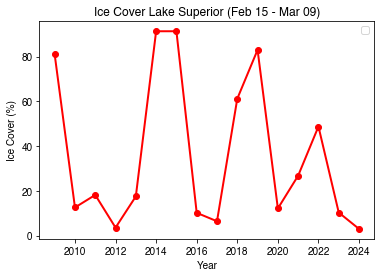

In [ ]:
# Get Ice Cover Data

ice_avg = []
for iyr in range(len(tlist)):
    year_start = str(int(tlist[iyr][0][0:4])-1)
    year_end = tlist[iyr][0][0:4]

    # # Convert year and doy to datetime
    # combined = df["year"]*1000 + df["day"]
    # df["date"] = pd.to_datetime(combined, format = "%Y%j")

    # Mask between dates of interest
    start_date = pd.to_datetime(tlist[iyr][0],format='%Y-%m-%d')
    end_date = pd.to_datetime(tlist[iyr][1],format='%Y-%m-%d')

    #greater than the start date and smaller than the end date
    mask = (df['date'] >= start_date) & (df['date'] <= end_date)

    df_mask = df.loc[mask]

    ice_avg.append(df_mask['value'].mean())

ice_avg = np.asarray(ice_avg)


# Plot ice averages

hh, ax = plt.subplots()

ax.plot(years, ice_avg, '-o',
              c='r', lw=2)

ax.set_xlabel('Year')
ax.set_ylabel('Ice Cover (%)')
ax.set_title('Ice Cover Lake '+lake+' ('+start_dates[0].strftime('%b %d')+' - '+end_dates[0].strftime('%b %d')+')')
ax.legend()

/tmp/ipykernel_6154/506866541.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral')
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


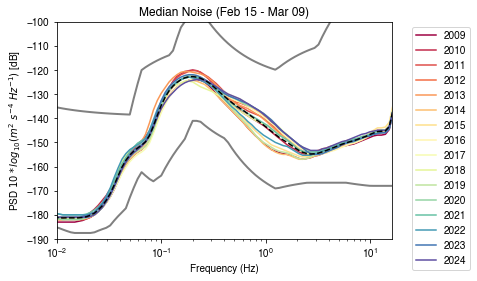

In [ ]:
plotunit = 2 # acceleration

def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

Nsm = 3

cmap = cm.get_cmap('Spectral')
rgb = cmap(np.linspace(0,1,len(tlist)))

hh, ax = plt.subplots()

for iyr in range(len(tlist)):
    ax.plot(freqs, smooth(PSDs[iyr],Nsm),
            c=rgb[iyr], lw=1.5, linestyle='-', label=tlist[iyr][0][0:4])

# ax.plot(freqs, PSDs[iyr],
            #   c='r', lw=4, linestyle='-')

ax.plot(freqs, smooth(PSD_avg,Nsm),
              c='k', lw=1.5, linestyle='--')

ax.set_xscale('log')
ax.set_xlim([1e-2, 16])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylim([-190, -100])
# ax.set_ylabel('Acceleration Power (dB)')
ax.set_ylabel(r'PSD $10*log_{10}(m^2 \,\, s^{-4} \,\, Hz^{-1})$ [dB]')
ax.set_title('Mean Noise ('+start_dates[0].strftime('%b %d')+' - '+end_dates[0].strftime('%b %d')+')')
ax.legend(bbox_to_anchor=(1.25, 1.0))

ax.plot(freqs, 10*np.log10(accNLNM(freqs) / (2*np.pi*freqs)**(2-plotunit)),
              c='gray', label='NLNM',lw=2)
ax.plot(freqs, 10*np.log10(accNHNM(freqs) / (2*np.pi*freqs)**(2-plotunit)),
            c='gray', label='NHNM',lw=2)


plt.savefig(figdir+'c2_noise_psd_'+station+'_sm'+str(Nsm)+'.pdf', bbox_inches='tight')

/tmp/ipykernel_6154/3124183059.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral')
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


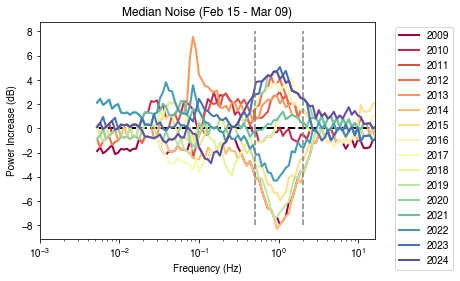

In [ ]:
cmap = cm.get_cmap('Spectral')
rgb = cmap(np.linspace(0,1,len(tlist)))

hh, ax = plt.subplots()

ax.plot(freqs, PSD_avg*0,
              c='k', lw=2, linestyle='--')

dPSD_avg = []
for iyr in range(len(tlist)):

    dPSD = PSDs[iyr] - PSD_avg

    dPSD_avg.append(np.mean(dPSD[(freqs>=fmin) & (freqs<=fmax)]))

    ax.plot(freqs, dPSD,
            c=rgb[iyr], lw=2, linestyle='-', label=tlist[iyr][0][0:4])

dPSD_avg = np.asarray(dPSD_avg)

# ax.plot(station.freqs[dof], 10*np.log10(station.text_percentiles[dof][50]/(2*np.pi*station.freqs[dof])**(2-plotunit)),
#               c='r', lw=4, linestyle='-')

ax.plot([fmin, fmin],[-8, 8],'--',color='gray')
ax.plot([fmax, fmax],[-8, 8],'--',color='gray')

ax.set_xscale('log')
ax.set_xlim([1e-3, 16])
ax.set_xlabel('Frequency (Hz)')
# ax.set_ylim([-190, -100])
ax.set_ylabel('Power Increase (dB)')
ax.set_title('Mean Noise ('+start_dates[0].strftime('%b %d')+' - '+end_dates[0].strftime('%b %d')+')')
ax.legend(bbox_to_anchor=(1.25, 1.0))

# plt.savefig(figdir+'noise_powerincrease_'+station+'.pdf', bbox_inches='tight')

/tmp/ipykernel_6154/2008133517.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral')
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


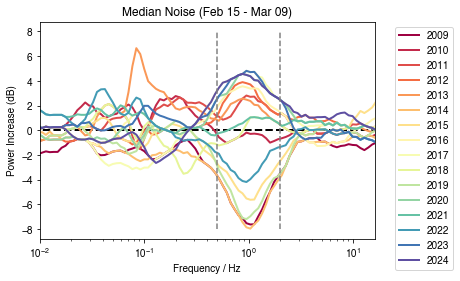

In [ ]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

Nsm = 3

cmap = cm.get_cmap('Spectral')
rgb = cmap(np.linspace(0,1,len(tlist)))

hh, ax = plt.subplots()

ax.plot(freqs, PSD_avg*0,
              c='k', lw=2, linestyle='--')

dPSD_avg = []
for iyr in range(len(tlist)):

    dPSD = PSDs[iyr] - PSD_avg

    dPSD = smooth(dPSD,Nsm)

    dPSD_avg.append(np.mean(dPSD[(freqs>=fmin) & (freqs<=fmax)]))

    ax.plot(freqs, dPSD,
            c=rgb[iyr], lw=2, linestyle='-', label=tlist[iyr][0][0:4])

dPSD_avg = np.asarray(dPSD_avg)

# ax.plot(station.freqs[dof], 10*np.log10(station.text_percentiles[dof][50]/(2*np.pi*station.freqs[dof])**(2-plotunit)),
#               c='r', lw=4, linestyle='-')

ax.plot([fmin, fmin],[-8, 8],'--',color='gray')
ax.plot([fmax, fmax],[-8, 8],'--',color='gray')

ax.set_xscale('log')
ax.set_xlim([1e-2, 16])
ax.set_xlabel('Frequency / Hz')
# ax.set_ylim([-190, -100])
ax.set_ylabel('PSD Difference from Mean (dB)')
ax.set_title('Mean Noise ('+start_dates[0].strftime('%b %d')+' - '+end_dates[0].strftime('%b %d')+')')
ax.legend(bbox_to_anchor=(1.25, 1.0))

plt.savefig(figdir+'c2_noise_powerincrease_'+station+'_sm'+str(Nsm)+'.pdf', bbox_inches='tight')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


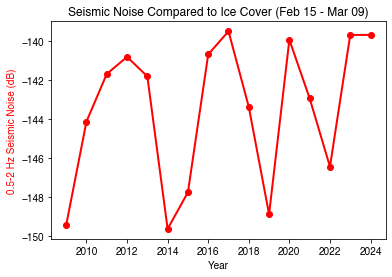

In [ ]:
# Calculate R^2 for seismic noise and ice cover
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(ice_avg[~np.isnan(PSD_band)], PSD_band[~np.isnan(PSD_band)])

R2 = r_value**2

years_pred = years[~np.isnan(PSD_band)]
PSD_band_pred = PSD_band[~np.isnan(PSD_band)]
# ice_avg_pred = slope * PSD_band_pred + intercept
ice_avg_pred = (PSD_band_pred - intercept) / slope

# Plot Average within band compared to ice cover

hh, ax = plt.subplots()

ax.plot(years[~np.isnan(PSD_band)], PSD_band[~np.isnan(PSD_band)], '-o',
              c='r', lw=2)
# ax.set_ylim([-190, -100])
ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)', color='r')

# ax2 = ax.twinx()
# ax2.plot(years, ice_avg, '-o', c='b', lw=2)
# # ax2.plot(years_pred, ice_avg_pred, '--', c='b', lw=2)
# ax2.set_ylabel('Lake '+lake+' Ice Cover (%)', color='b')

# ax.annotate("$R^2$ = {:.3f}".format(R2), (0.05, 0.93), xycoords='axes fraction')

# ax.set_xlim([5e-3, 16])
ax.set_xlabel('Year')
ax.set_title('Seismic Noise Compared to Ice Cover ('+start_dates[0].strftime('%b %d')+' - '+end_dates[0].strftime('%b %d')+')')
# ax.legend()

# plt.savefig(figdir+'noise_icecover_compare_'+station+'_'+lake+'.pdf',bbox_inches='tight')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


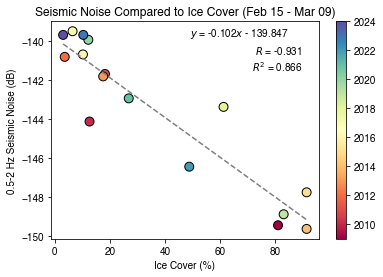

In [ ]:
# Plot Average within band compared to ice cover

hh, ax = plt.subplots()

sc = ax.scatter(ice_avg[~np.isnan(PSD_band)], PSD_band[~np.isnan(PSD_band)], marker='o', s=80,
              c=years[~np.isnan(PSD_band)], cmap='Spectral', edgecolor='black')
# ax.set_ylim([-190, -100])
cb = plt.colorbar(sc)

ax.plot([ice_avg.min(),ice_avg.max()], [ice_avg.min()*slope,ice_avg.max()*slope]+intercept, '--',color='gray')

ax.annotate("$y$ = {:.3f}$x$ - {:.3f}".format(slope,np.abs(intercept)), (0.52, 0.93), xycoords='axes fraction')
ax.annotate("$R$ = {:.3f}".format(r_value), (0.76, 0.85), xycoords='axes fraction')
ax.annotate("$R^2$ = {:.3f}".format(R2), (0.75, 0.77), xycoords='axes fraction')

ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)')

# ax.set_xlim([5e-3, 16])
ax.set_xlabel('Ice Cover (%)')
ax.set_title('Seismic Noise Compared to Ice Cover ('+start_dates[0].strftime('%b %d')+' - '+end_dates[0].strftime('%b %d')+')')
# ax.legend()

# plt.savefig(figdir+'noise_icecover_compare_'+station+'_'+lake+'_scatter.pdf', bbox_inches='tight')

/Users/russell/anaconda3/envs/sitesearch/lib/python3.11/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/Users/russell/anaconda3/envs/sitesearch/lib/python3.11/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


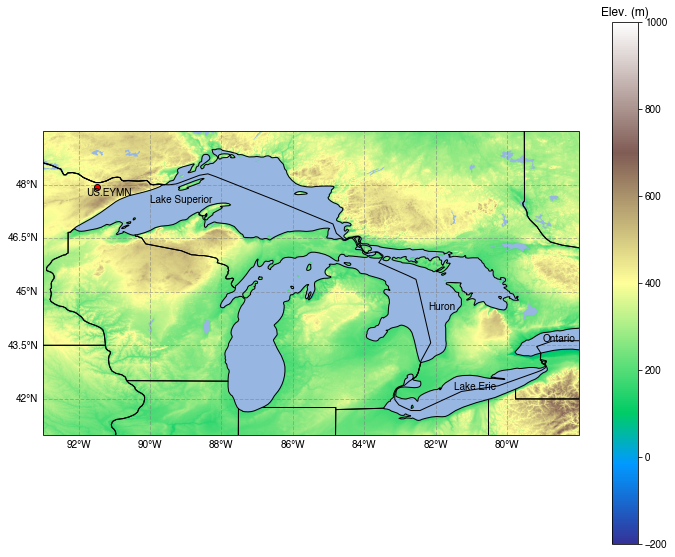

In [ ]:

client = Client("IRIS")
inventory = client.get_stations(network=network, station=station)

stalat = inventory[0][0].latitude
stalon = inventory[0][0].longitude

# Load Topography dataset
path2grdfile = '/Users/russell/Lamont/GMT/grids/etopo1.grd'
etopodata = Dataset(path2grdfile)
lons_e = np.linspace(etopodata.variables['x_range'][0],
                    etopodata.variables['x_range'][1],
                    etopodata.variables['dimension'][0])
lats_e = np.linspace(etopodata.variables['y_range'][0],
                    etopodata.variables['y_range'][1],
                    etopodata.variables['dimension'][1])
etopo = etopodata.variables['z'][:]
etopo = np.reshape(etopo,etopodata.variables['dimension'][::-1])

# Generate the map
# Map projection
data_proj = ccrs.PlateCarree()
# data_proj = ccrs.Mercator()
fig = plt.figure(figsize=(12,12))
ax = plt.axes(projection=data_proj)
# ax.set_extent([stalon-3.5, stalon+1, stalat-1, stalat+2], crs=data_proj)
ax.set_extent([-93, -78, 41, 49.5], crs=data_proj)
img_extent = (-180, 180, -90, 90)
pos = ax.imshow(etopo, origin='upper', extent=img_extent, transform=data_proj,
            cmap='terrain', alpha=1, zorder=-1)
cb = plt.colorbar(pos, ax=ax, shrink=0.8)
cb.ax.set_title('Elev. (m)')
cmax = etopo.max()
cmin = etopo.min()
pos.set_clim(-200,1000)
ax.add_feature(cfeature.OCEAN,facecolor=cfeature.COLORS['water'])
ax.add_feature(cfeature.LAKES.with_scale('10m'), facecolor=cfeature.COLORS['water'], zorder=0)
# ax.add_feature(cfeature.RIVERS)
ax.coastlines(zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'))
ax.add_feature(cfeature.STATES.with_scale('50m'))
ax.annotate('Lake Erie', (-81.5,42.25), xycoords='data', transform=data_proj, color='k')
ax.annotate('Huron', (-82.2,44.5), xycoords='data', transform=data_proj, color='k')
ax.annotate('Ontario', (-79,43.6), xycoords='data', transform=data_proj, color='k')
ax.annotate('Lake Superior', (-90,47.5), xycoords='data', transform=data_proj, color='k')

# Plot station
ax.plot(
    stalon,stalat, marker='o',
    c='r',
    markeredgecolor='black', transform=data_proj)
# ax.set_xlim(minlongitude,maxlongitude)
# ax.set_ylim(minlatitude,maxlatitude)
ax.annotate(network+'.'+station, (stalon-0.3,stalat-0.25), xycoords='data', transform=data_proj, color='k')

gl = ax.gridlines(crs=data_proj, draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=0)
gl.xlabels_top = False
gl.ylabels_right = False

# plt.savefig(figdir+'station_map_'+station+'_'+lake+'.pdf')



/Users/russell/anaconda3/envs/sitesearch/lib/python3.11/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/Users/russell/anaconda3/envs/sitesearch/lib/python3.11/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


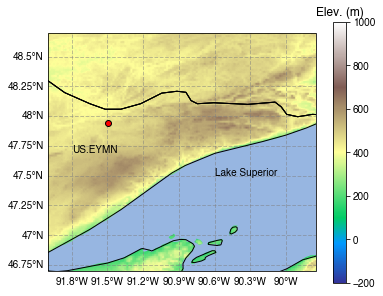

In [ ]:
# Zoom

network = 'US'
station = 'EYMN'

client = Client("IRIS")
inventory = client.get_stations(network=network, station=station)

stalat = inventory[0][0].latitude
stalon = inventory[0][0].longitude

# Load Topography dataset
path2grdfile = '/Users/russell/Lamont/GMT/grids/etopo1.grd'
etopodata = Dataset(path2grdfile)
lons_e = np.linspace(etopodata.variables['x_range'][0],
                    etopodata.variables['x_range'][1],
                    etopodata.variables['dimension'][0])
lats_e = np.linspace(etopodata.variables['y_range'][0],
                    etopodata.variables['y_range'][1],
                    etopodata.variables['dimension'][1])
etopo = etopodata.variables['z'][:]
etopo = np.reshape(etopo,etopodata.variables['dimension'][::-1])

# Generate the map
# Map projection
data_proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection=data_proj)
ax.set_extent([stalon-1/2, stalon+3.5/2, stalat-2.5/2, stalat+1.5/2], crs=data_proj)
img_extent = (-180, 180, -90, 90)
pos = ax.imshow(etopo, origin='upper', extent=img_extent, transform=data_proj,
            cmap='terrain', alpha=1, zorder=-1)
cb = plt.colorbar(pos, ax=ax, shrink=0.8)
cb.ax.set_title('Elev. (m)')
cmax = etopo.max()
cmin = etopo.min()
pos.set_clim(-200,1000)
ax.add_feature(cfeature.OCEAN,facecolor=cfeature.COLORS['water'])
ax.add_feature(cfeature.LAKES.with_scale('10m'), facecolor=cfeature.COLORS['water'], zorder=0)
# ax.add_feature(cfeature.RIVERS)
ax.coastlines(zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'))
ax.add_feature(cfeature.STATES.with_scale('50m'))
ax.annotate('Lake Superior', (-90.6,47.5), xycoords='data', transform=data_proj, color='k')

# Plot station
ax.plot(
    stalon,stalat, marker='o',
    c='r',
    markeredgecolor='black', transform=data_proj)
# ax.set_xlim(minlongitude,maxlongitude)
# ax.set_ylim(minlatitude,maxlatitude)
ax.annotate(network+'.'+station, (stalon-0.3,stalat-0.25), xycoords='data', transform=data_proj, color='k')

gl = ax.gridlines(crs=data_proj, draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=0)
gl.xlabels_top = False
gl.ylabels_right = False

# plt.savefig('./figs/station_map_EYMN_zoom.pdf')